In [62]:
import numpy as np
import matplotlib.pyplot as plt

loss_path = "./results/Cousteau/losses_nonlinearDecoder_gradient.npz"
losses = np.load(loss_path, allow_pickle=False)

# Scaled loss values (λᵢ(t) * Lᵢ(t)) — one value per epoch
epochs = np.arange(len(losses["total_loss"]))
rc     = losses["reconstruction"]
sp     = losses["latent_sparsity"]
rg     = losses["region_sparsity"]
orth   = losses["orthogonality"]

# Gradient norm logs — one value every grad_log_interval epochs
gn_epochs = losses["grad_norm_epochs"]
gn_rc     = losses["grad_norm_reconstruction"]
gn_sp     = losses["grad_norm_latent_sparsity"]
gn_rg     = losses["grad_norm_region_sparsity"]
gn_orth   = losses["grad_norm_orthogonality"]

In [63]:
print(gn_sp) 
print(sp) 

[12895.07284404  3906.4494313   4020.77743067  4883.38192681
  5191.55361219  5361.75002088  6580.09277993  5829.55164382
  4846.95481831  5606.7185022   5690.52493665  5965.81134919
  5519.22251378  6195.83372544  5691.82801661  5874.44516298
  5776.05379847  5869.13676684  6332.24692156  6070.32888788
  6382.78515584  5959.39900875  5935.75720025  5859.50327016
  5961.18359821  6751.23506754  5700.84170612  6504.07755664
  5695.61297917  5948.11628781  6268.73238633  6183.71504152
  5524.20266466  5556.89984811  5931.46469233  5766.58725777
  6389.84804856  5337.05083715  6013.43338939  6385.99681225
  6450.06700778  5666.09817186  5178.32846058  6946.23536972
  6814.36130632  5567.80823199  5578.16203812  6044.62333025
  6396.99052568  6179.76080898]
[5435.14451339 5316.0325425  5196.19710612 ... 3203.56041693 3192.28641293
 3207.29662373]


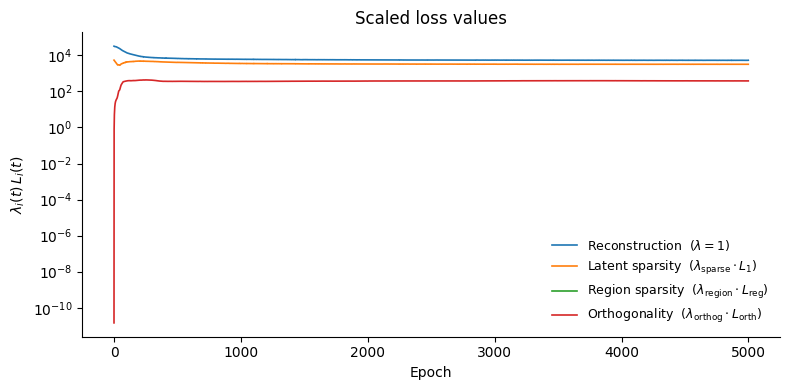

In [64]:
# ── Figure 3: Scaled loss values λᵢ(t) Lᵢ(t) ──────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
labels = [
    r"Reconstruction  ($\lambda=1$)",
    r"Latent sparsity  ($\lambda_{\mathrm{sparse}} \cdot L_1$)",
    r"Region sparsity  ($\lambda_{\mathrm{region}} \cdot L_{\mathrm{reg}}$)",
    r"Orthogonality  ($\lambda_{\mathrm{orthog}} \cdot L_{\mathrm{orth}}$)",
]

for y, c, lbl in zip([rc, sp, rg, orth], colors, labels):
    ax.plot(epochs, y, color=c, linewidth=1.2, label=lbl)

ax.set_xlabel("Epoch")
ax.set_ylabel(r"$\lambda_i(t)\, L_i(t)$")
ax.set_title("Scaled loss values")
ax.set_yscale("log")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

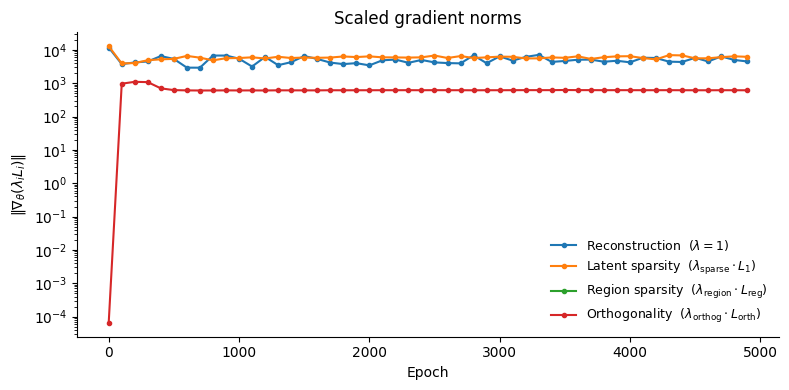

In [65]:
# ── Scaled gradient norms ‖∇_θ(λᵢ Lᵢ)‖ ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

for y, c, lbl in zip([gn_rc, gn_sp, gn_rg, gn_orth], colors, labels):
    ax.plot(gn_epochs, y, color=c, linewidth=1.5, marker="o", markersize=3, label=lbl)

ax.set_xlabel("Epoch")
ax.set_ylabel(r"$\|\nabla_\theta(\lambda_i L_i)\|$")
ax.set_title("Scaled gradient norms")
ax.set_yscale("log")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

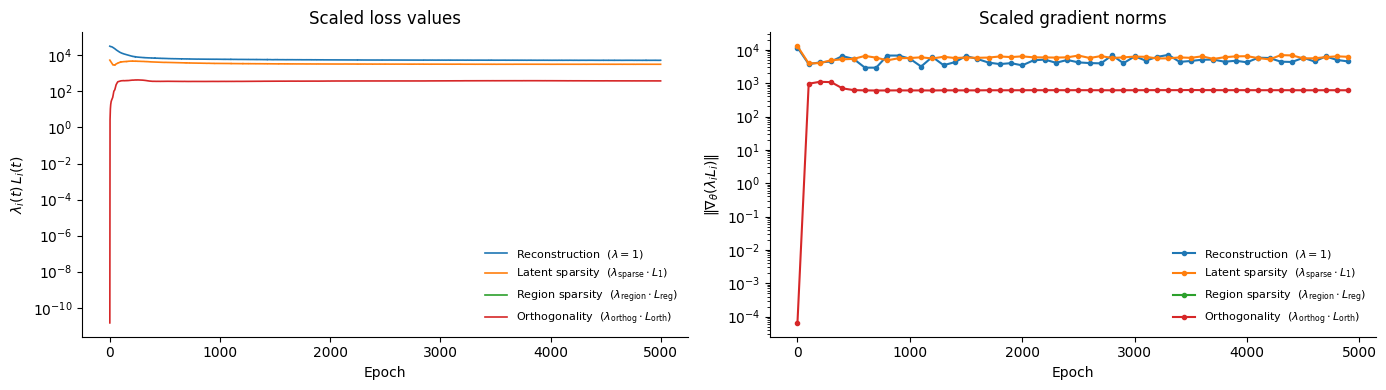

In [66]:
# ── Side-by-side summary ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: scaled losses
for y, c, lbl in zip([rc, sp, rg, orth], colors, labels):
    axes[0].plot(epochs, y, color=c, linewidth=1.2, label=lbl)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel(r"$\lambda_i(t)\, L_i(t)$")
axes[0].set_title("Scaled loss values")
axes[0].set_yscale("log")
axes[0].legend(frameon=False, fontsize=8)
axes[0].spines[["top", "right"]].set_visible(False)

# Right: gradient norms
for y, c, lbl in zip([gn_rc, gn_sp, gn_rg, gn_orth], colors, labels):
    axes[1].plot(gn_epochs, y, color=c, linewidth=1.5, marker="o", markersize=3, label=lbl)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel(r"$\|\nabla_\theta(\lambda_i L_i)\|$")
axes[1].set_title("Scaled gradient norms")
axes[1].set_yscale("log")
axes[1].legend(frameon=False, fontsize=8)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("./results/Cousteau/gradient_analysis.pdf", bbox_inches="tight")
plt.show()

('time', 'dist', 'dir', 'pos', 'cycleNum', 'condNum', 'worldPos', 'firstTimeEachCond', 'lastTimeEachCond', 'timeIndices', 'cellIDs', 'cellNames')
time <class 'numpy.ndarray'> (1, 70228)
dist <class 'numpy.ndarray'> (70228, 1)
dir <class 'numpy.ndarray'> (70228, 1)
pos <class 'numpy.ndarray'> (70228, 1)
cycleNum <class 'numpy.ndarray'> (70228, 1)
condNum <class 'numpy.ndarray'> (70228, 1)
worldPos <class 'numpy.ndarray'> (0, 0)
firstTimeEachCond <class 'numpy.ndarray'> (1, 20)
lastTimeEachCond <class 'numpy.ndarray'> (1, 20)
timeIndices <class 'numpy.ndarray'> (0, 0)
cellIDs <class 'numpy.ndarray'> (1, 4)
cellNames <class 'scipy.io.matlab._mio5_params.MatlabOpaque'> (1,)


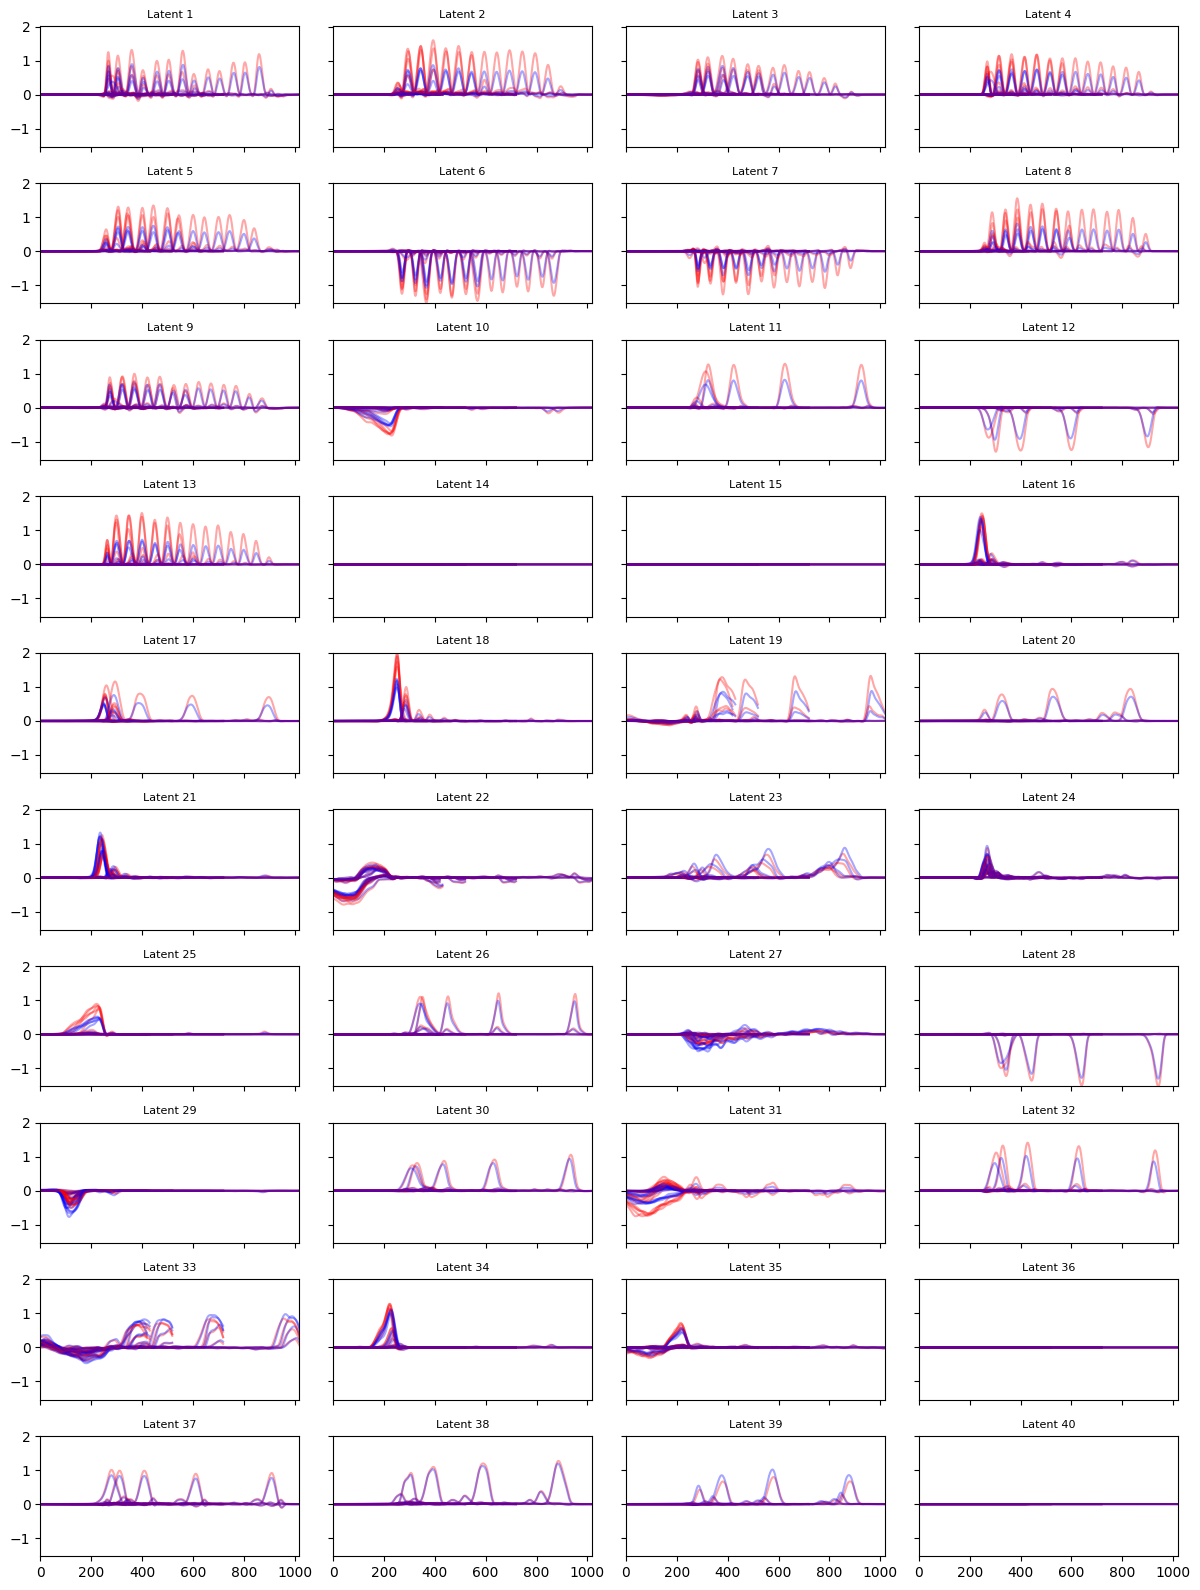

In [67]:

import msca
from msca.models import mSCA
import scipy.io as sio

mat = sio.loadmat("./data/Cousteau_interp_cycling_m1_rawRates.mat")
mask = mat["mask"]

print(mask.dtype.names)  
for k in mask.dtype.names:
    v = mask[k][0, 0]
    print(k, type(v), getattr(v, "shape", None))

import importlib
import os
import numpy as np
from scipy import io


def load_data(dir_path, f):
    # Load in matlab file
    mat_file = io.loadmat(dir_path + f)

    # Grab data and mask
    data_array = mat_file["data"]
    mask = mat_file["mask"]

    # Grab the start and end indices for each trial
    start_idxs = mat_file["mask"]["firstTimeEachCond"][0][0].squeeze() - 1
    end_idxs = mat_file["mask"]["lastTimeEachCond"][0][0].squeeze()

    return data_array, mask, start_idxs, end_idxs


# Preprocess the loaded data and split into trials
def preprocess(data_array, start_idxs, end_idxs, downsample_factor=5):
    """
    Pre-processing done by Andrew Zimnik
    """
    # Downsample the data
    if downsample_factor is not None:
        data_downsamp = data_array[::downsample_factor]

        # Adjust the start and end indices to account for the downsampling
        start_idxs = start_idxs // downsample_factor
        end_idxs = end_idxs // downsample_factor
    else:
        data_downsamp = data_array

    # Transpose the data to N x TC
    data_concat = data_downsamp.T

    # fr range (for normalizing later)
    fr_range = np.ptp(data_concat, axis=1)[:, None]

    # Soft normalize (divide each neuron by its range + 5)
    data_norm = data_concat / (fr_range + 5)

    # mean-center each neuron
    data_snm_norm = data_norm - np.mean(data_norm, axis=1)[:, None]

    # rename the data for convenience
    # Note that model requires (T x N) input rather than (N x T), which is why there are transposes below
    fit_data = np.copy(data_snm_norm.T)

    # Split the data into trials
    split_data = [fit_data[i:j] for i, j in zip(start_idxs, end_idxs)]

    return split_data




fp = "./data/"
m1_data, m1_mask, m1_start_idxs, m1_end_idxs = load_data(
    f"{fp}", "Cousteau_interp_cycling_m1_rawRates.mat"
)
sma_data, sma_mask, sma_start_idxs, sma_end_idxs = load_data(
    f"{fp}", "Cousteau_interp_cycling_sma_rawRates.mat"
)

# Preprocess the data
m1_preprocessed = preprocess(
    m1_data, m1_start_idxs, m1_end_idxs, downsample_factor=5
)
sma_preprocessed = preprocess(
    sma_data, sma_start_idxs, sma_end_idxs, downsample_factor=5
)

# Put data into dictionary format
X = {"M1": m1_preprocessed, "SMA": sma_preprocessed}


msca= mSCA(
        n_components=40,
        n_epochs=5000,
        linear=False, # nonlinear encoder 
        loss_func="Gaussian",
        lam_sparse="adaptive", # this is set to 0.05 in simulations -> this is not adaptive 
        lam_orthog=0.1,
        lam_region=0.0,
        decoder_type="nonlinear", # nonlinear decoder
        decoder_hidden_size=40,
    
        decoder_activation="GeLU",
        post_hoc_epoch=-1,
        cd_rate=0.5,
        cd_mode="both",
        filter_len=41,
        init="unique",
        decoder_init_mode = "pca",

    )
msca.load("./results/Cousteau/msca_nonlinearDecoder_gradient.pt", X)

import torch
import torch._dynamo
import numpy as np
import matplotlib.pyplot as plt

torch._dynamo.config.suppress_errors = True

# get the learned latent trajectories of two regions 
# red is M1, blue is SMA
# there are 40 latent components in total, we will plot them all but only show the first 20 trials for visualization purposes
# plot everything on the same y-axis scale for easier comparison across components and regions
Z = msca.transform(X)

n_components = 40
# there are 20 trails for each region
n_trials = min(20, len(Z['M1']), len(Z['SMA']))

# Global y-range across all plotted traces so every subplot uses the same scale
all_vals = []
for j in range(n_trials):
    all_vals.append(Z['M1'][j][:, :n_components].ravel())
    all_vals.append(Z['SMA'][j][:, :n_components].ravel())
all_vals = np.concatenate(all_vals)
ymin, ymax = np.min(all_vals), np.max(all_vals)

# Global x-range across all plotted traces
max_t = max(max(Z['M1'][j].shape[0], Z['SMA'][j].shape[0]) for j in range(n_trials))

fig, axs = plt.subplots(10, 4, figsize=(12, 16), sharex=True, sharey=True)
for i in range(n_components): # plot each component in its own subplot
    ax = axs[i // 4, i % 4]
    for j in range(n_trials): # plot 20 trails per region on the same subplot
        ax.plot(Z['M1'][j][:, i], c='r', alpha=0.35)
        ax.plot(Z['SMA'][j][:, i], c='b', alpha=0.35)
    ax.set_xlim(0, max_t - 1)
    ax.set_ylim(ymin, ymax)
    ax.set_title(f'Latent {i + 1}', fontsize=8)

plt.tight_layout()
plt.show()